# UPI Transaction Intelligence & Fraud Analytics — 2024
### IBM SkillsBuild Data Analytics with AI Academic Internship

**Author:** Sairam Ranveerkar  
**Dataset:** 2024 UPI transaction dataset  
**Objective:** Analyze payment performance, customer behavior, banking/merchant trends, fraud-flagged transactions, and potential transaction-volume anomalies.

> **Interpretation note:** `fraud_flag = 1` is a dataset-provided flag. It is reported as a *fraud-flagged transaction*, not as independently confirmed fraud.


## 1. Setup


In [1]:
import json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)

DATA_FILE = Path("upi_transactions_2024_clean.csv")
OUTPUT_DIR = Path("analysis_outputs")          # CSV / JSON tables
CHART_DIR = Path("charts")                     # PNG charts
DASH_DIR = Path("dashboard")                   # dashboard data feed
for d in (OUTPUT_DIR, CHART_DIR, DASH_DIR):
    d.mkdir(exist_ok=True)

print("Working directory:", Path.cwd())
print("Dataset:", DATA_FILE)

Working directory: C:\Users\shiva\Downloads\UPI-Transactions-Intelligence-2024 IBM\UPI-Transcations-Intelligence-2024
Dataset: upi_transactions_2024_clean.csv


## 2. Load and validate the dataset


In [2]:
df = pd.read_csv(DATA_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Shape:", df.shape)
display(df.head())


Shape: (89019, 22)


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date,month,month_name,quarter,year_month
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,2024-10-08,10,Oct,Q4,2024-10
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,2024-04-11,4,Apr,Q2,2024-04
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,2024-04-02,4,Apr,Q2,2024-04
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,2024-01-07,1,Jan,Q1,2024-01
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,2024-01-23,1,Jan,Q1,2024-01


In [3]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate transaction IDs:", int(df["transaction_id"].duplicated().sum()))
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Missing values: 0
Duplicate transaction IDs: 0
Date range: 2024-01-01 00:33:20 to 2024-12-30 23:55:40

Data types:


,dtype
transaction_id,object
timestamp,datetime64[ns]
transaction_type,object
merchant_category,object
amount_inr,int64
transaction_status,object
sender_age_group,object
receiver_age_group,object
sender_state,object
sender_bank,object


In [4]:
# Data-quality rules: fail loudly if the input file is not what the analysis expects.
assert df["timestamp"].notna().all(), "Unparseable timestamps"
assert (df["amount_inr"] > 0).all(), "Non-positive amounts"
assert set(df["transaction_status"].unique()) <= {"SUCCESS", "FAILED"}, "Unexpected status values"
assert set(df["fraud_flag"].unique()) <= {0, 1}, "fraud_flag must be 0/1"
assert (df["timestamp"].dt.hour == df["hour_of_day"]).all(), "hour_of_day disagrees with timestamp"
df["failed"] = (df["transaction_status"] == "FAILED").astype(int)
print("All data-quality checks passed.")

All data-quality checks passed.


## 3. KPI summary


In [5]:
total_transactions = len(df)
total_value = df["amount_inr"].sum()
average_amount = df["amount_inr"].mean()
median_amount = df["amount_inr"].median()
successful = (df["transaction_status"].str.upper() == "SUCCESS").sum()
failed = (df["transaction_status"].str.upper() == "FAILED").sum()
fraud_flagged = df["fraud_flag"].sum()
fraud_flagged_amount = df.loc[df["fraud_flag"] == 1, "amount_inr"].sum()

kpi = pd.DataFrame({
    "Metric": [
        "Total Transactions", "Total Transaction Value (INR)",
        "Average Transaction (INR)", "Median Transaction (INR)",
        "Minimum Transaction (INR)", "Maximum Transaction (INR)",
        "Successful Transactions", "Failed Transactions",
        "Success Rate (%)", "Failure Rate (%)",
        "Fraud-Flagged Transactions", "Fraud-Flag Rate (%)",
        "Fraud-Flagged Amount (INR)"
    ],
    "Value": [
        total_transactions, total_value, average_amount, median_amount,
        df["amount_inr"].min(), df["amount_inr"].max(),
        successful, failed, successful/total_transactions*100,
        failed/total_transactions*100, fraud_flagged,
        fraud_flagged/total_transactions*100, fraud_flagged_amount
    ]
})
display(kpi)
kpi.to_csv(OUTPUT_DIR / "kpi_summary.csv", index=False)


,Metric,Value
0,Total Transactions,"89,019.00"
1,Total Transaction Value (INR),"116,495,487.00"
2,Average Transaction (INR),"1,308.66"
3,Median Transaction (INR),628.00
4,Minimum Transaction (INR),10.00
5,Maximum Transaction (INR),"34,304.00"
6,Successful Transactions,"84,640.00"
7,Failed Transactions,"4,379.00"
8,Success Rate (%),95.08
9,Failure Rate (%),4.92


## 4. Monthly transaction analysis


In [6]:
monthly = df.groupby("year_month", sort=True).agg(
    transactions=("transaction_id","count"),
    transaction_value_inr=("amount_inr","sum"),
    average_amount_inr=("amount_inr","mean"),
    failed_transactions=("transaction_status", lambda s: (s.str.upper()=="FAILED").sum()),
    fraud_flags=("fraud_flag","sum")
).reset_index()
monthly["failure_rate_pct"] = monthly["failed_transactions"]/monthly["transactions"]*100
monthly["fraud_flag_rate_pct"] = monthly["fraud_flags"]/monthly["transactions"]*100
display(monthly)
monthly.to_csv(OUTPUT_DIR / "monthly_analysis.csv", index=False)


,year_month,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,2024-01,7674,9851233,"1,283.72",366,17,4.77,0.22
1,2024-02,6953,9112229,"1,310.55",345,13,4.96,0.19
2,2024-03,7553,9925136,"1,314.07",384,13,5.08,0.17
3,2024-04,7313,9562714,"1,307.63",356,5,4.87,0.07
4,2024-05,7595,9951407,"1,310.26",382,11,5.03,0.14
5,2024-06,7230,9314982,"1,288.38",342,14,4.73,0.19
6,2024-07,7559,9899613,"1,309.65",370,21,4.89,0.28
7,2024-08,7632,9963909,"1,305.54",363,11,4.76,0.14
8,2024-09,7375,9702776,"1,315.63",372,10,5.04,0.14
9,2024-10,7499,9943742,"1,326.01",352,21,4.69,0.28


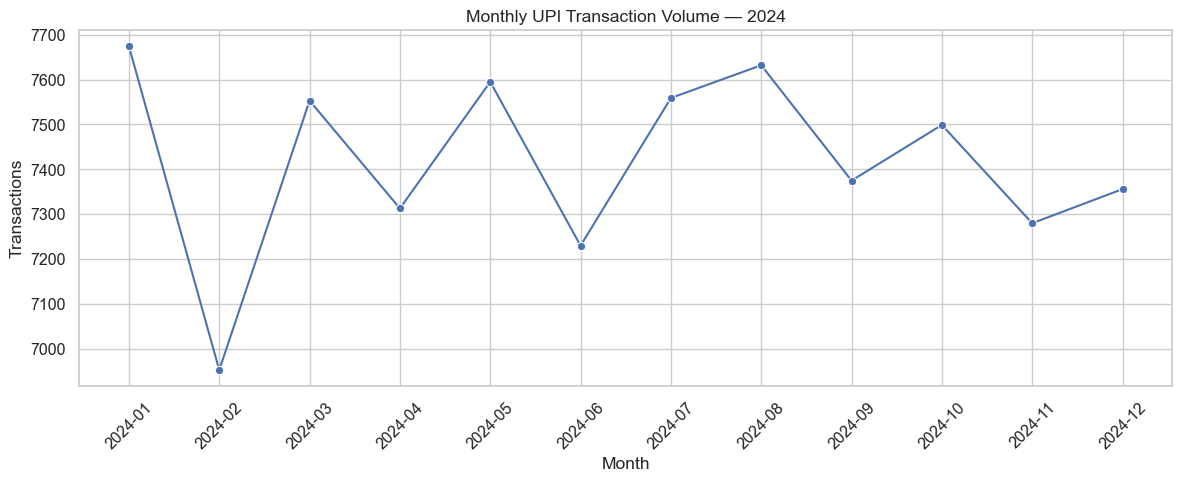

In [7]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x="year_month", y="transactions", marker="o")
plt.title("Monthly UPI Transaction Volume — 2024")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "monthly_transaction_volume.png", dpi=160)
plt.show()


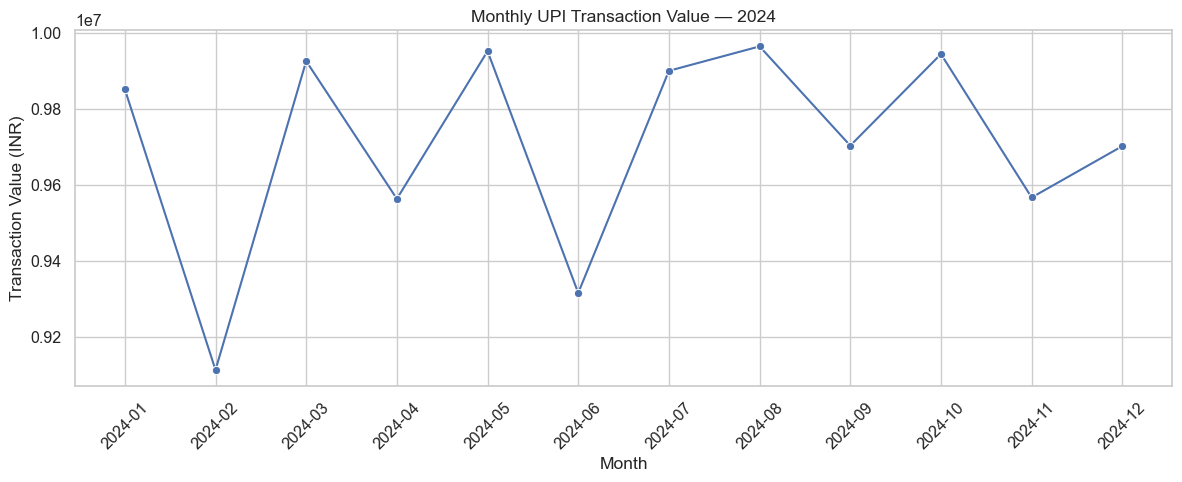

In [8]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x="year_month", y="transaction_value_inr", marker="o")
plt.title("Monthly UPI Transaction Value — 2024")
plt.xlabel("Month")
plt.ylabel("Transaction Value (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "monthly_transaction_value.png", dpi=160)
plt.show()


## 5. Transaction type and merchant analysis


In [9]:
def grouped_analysis(column):
    out = df.groupby(column).agg(
        transactions=("transaction_id","count"),
        transaction_value_inr=("amount_inr","sum"),
        average_amount_inr=("amount_inr","mean"),
        failed_transactions=("transaction_status", lambda s: (s.str.upper()=="FAILED").sum()),
        fraud_flags=("fraud_flag","sum")
    ).reset_index()
    out["failure_rate_pct"] = out["failed_transactions"]/out["transactions"]*100
    out["fraud_flag_rate_pct"] = out["fraud_flags"]/out["transactions"]*100
    return out

transaction_type = grouped_analysis("transaction_type")
merchant = grouped_analysis("merchant_category")

display(transaction_type.sort_values("transaction_value_inr", ascending=False))
display(merchant.sort_values("transaction_value_inr", ascending=False))

transaction_type.to_csv(OUTPUT_DIR / "transaction_type_analysis.csv", index=False)
merchant.to_csv(OUTPUT_DIR / "merchant_analysis.csv", index=False)


,transaction_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
2,P2P,40191,52815672,"1,314.12",1920,73,4.78,0.18
1,P2M,31095,40648458,"1,307.23",1538,56,4.95,0.18
0,Bill Payment,13351,17412227,"1,304.19",682,26,5.11,0.19
3,Recharge,4382,5619130,"1,282.32",239,10,5.45,0.23


,merchant_category,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
7,Shopping,10474,27449899,"2,620.77",530,20,5.06,0.19
4,Grocery,17675,20637981,"1,167.64",862,34,4.88,0.19
9,Utilities,7981,18610171,"2,331.81",396,10,4.96,0.13
3,Fuel,9032,13976679,"1,547.46",440,19,4.87,0.21
0,Education,2675,13479391,"5,039.02",123,4,4.60,0.15
6,Other,8839,7490341,847.42,430,20,4.86,0.23
2,Food,13367,7152649,535.10,693,25,5.18,0.19
1,Entertainment,7291,3005426,412.21,343,10,4.70,0.14
5,Healthcare,4501,2467211,548.15,216,9,4.80,0.20
8,Transport,7184,2225739,309.82,346,14,4.82,0.19


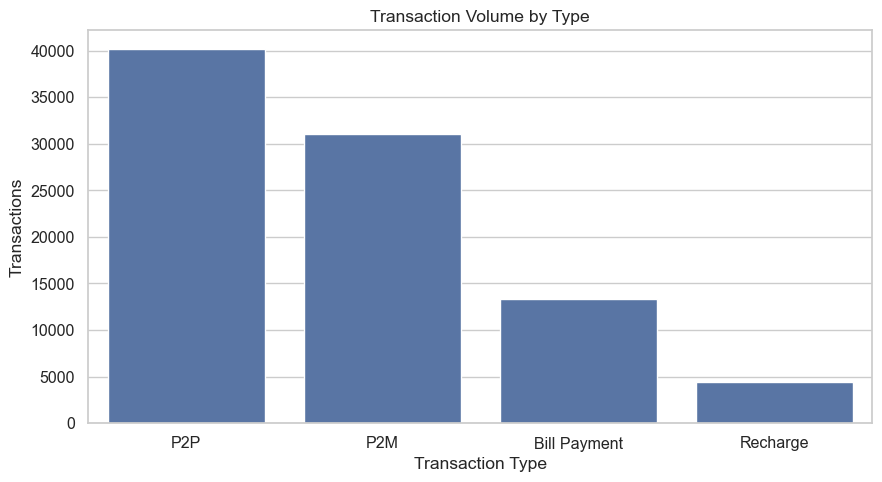

In [10]:
plt.figure(figsize=(9,5))
sns.barplot(data=transaction_type.sort_values("transactions", ascending=False),
            x="transaction_type", y="transactions")
plt.title("Transaction Volume by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transactions")
plt.tight_layout()
plt.savefig(CHART_DIR / "transaction_type_volume.png", dpi=160)
plt.show()


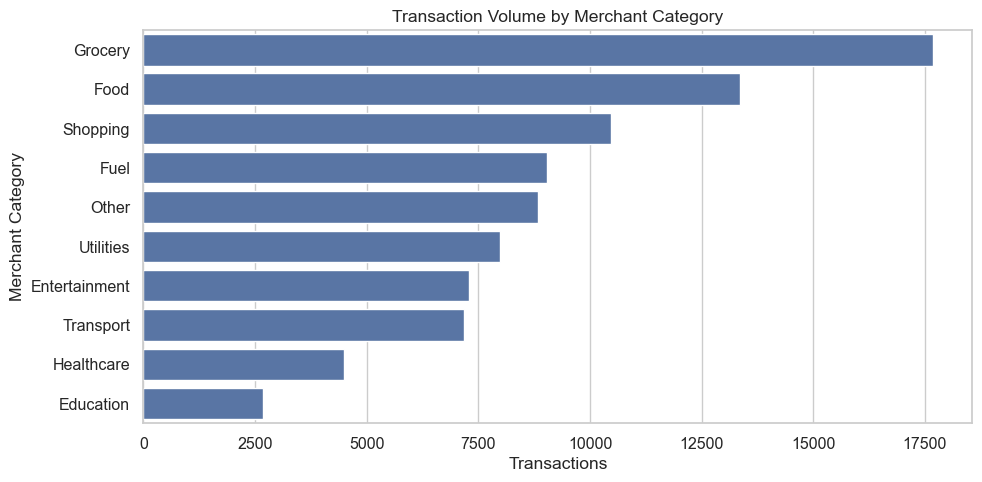

In [11]:
plt.figure(figsize=(10,5))
top_m = merchant.sort_values("transactions", ascending=False)
sns.barplot(data=top_m, x="transactions", y="merchant_category")
plt.title("Transaction Volume by Merchant Category")
plt.xlabel("Transactions")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.savefig(CHART_DIR / "merchant_category_volume.png", dpi=160)
plt.show()


## 6. Regional and banking analysis


In [12]:
state = grouped_analysis("sender_state")
sender_bank = grouped_analysis("sender_bank")
receiver_bank = grouped_analysis("receiver_bank")

display(state.sort_values("transaction_value_inr", ascending=False).head(10))
display(sender_bank.sort_values("transaction_value_inr", ascending=False))
display(receiver_bank.sort_values("transaction_value_inr", ascending=False))

state.to_csv(OUTPUT_DIR / "state_analysis.csv", index=False)
sender_bank.to_csv(OUTPUT_DIR / "sender_bank_analysis.csv", index=False)
receiver_bank.to_csv(OUTPUT_DIR / "receiver_bank_analysis.csv", index=False)


,sender_state,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
4,Maharashtra,13099,17019090,"1,299.27",629,15,4.80,0.11
8,Uttar Pradesh,10798,14257656,"1,320.40",564,15,5.22,0.14
3,Karnataka,10670,14027846,"1,314.70",526,29,4.93,0.27
1,Delhi,8827,11767227,"1,333.09",451,20,5.11,0.23
6,Tamil Nadu,9171,11669807,"1,272.47",473,11,5.16,0.12
7,Telangana,8018,10618623,"1,324.35",384,17,4.79,0.21
5,Rajasthan,7144,9603377,"1,344.26",324,19,4.54,0.27
0,Andhra Pradesh,6999,9249959,"1,321.61",355,9,5.07,0.13
9,West Bengal,7242,9241682,"1,276.12",362,16,5.00,0.22
2,Gujarat,7051,9040220,"1,282.12",311,14,4.41,0.20


,sender_bank,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
6,SBI,22273,29048869,"1,304.22",1096,35,4.92,0.16
1,HDFC,13363,17616659,"1,318.32",636,21,4.76,0.16
2,ICICI,10714,13757352,"1,284.05",537,23,5.01,0.21
5,PNB,8891,11819112,"1,329.33",459,15,5.16,0.17
0,Axis,8876,11774344,"1,326.54",431,19,4.86,0.21
3,IndusInd,8965,11648540,"1,299.34",408,16,4.55,0.18
7,Yes Bank,8774,11310508,"1,289.09",455,22,5.19,0.25
4,Kotak,7163,9520103,"1,329.07",357,14,4.98,0.20


,receiver_bank,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
6,SBI,22266,29271506,"1,314.63",1084,38,4.87,0.17
1,HDFC,13278,17454461,"1,314.54",666,21,5.02,0.16
2,ICICI,10702,14030488,"1,311.02",513,17,4.79,0.16
7,Yes Bank,8988,11714566,"1,303.36",408,22,4.54,0.24
3,IndusInd,8972,11620522,"1,295.20",455,20,5.07,0.22
0,Axis,8807,11579234,"1,314.78",472,18,5.36,0.20
5,PNB,8804,11447198,"1,300.23",431,20,4.90,0.23
4,Kotak,7202,9377512,"1,302.07",350,9,4.86,0.12


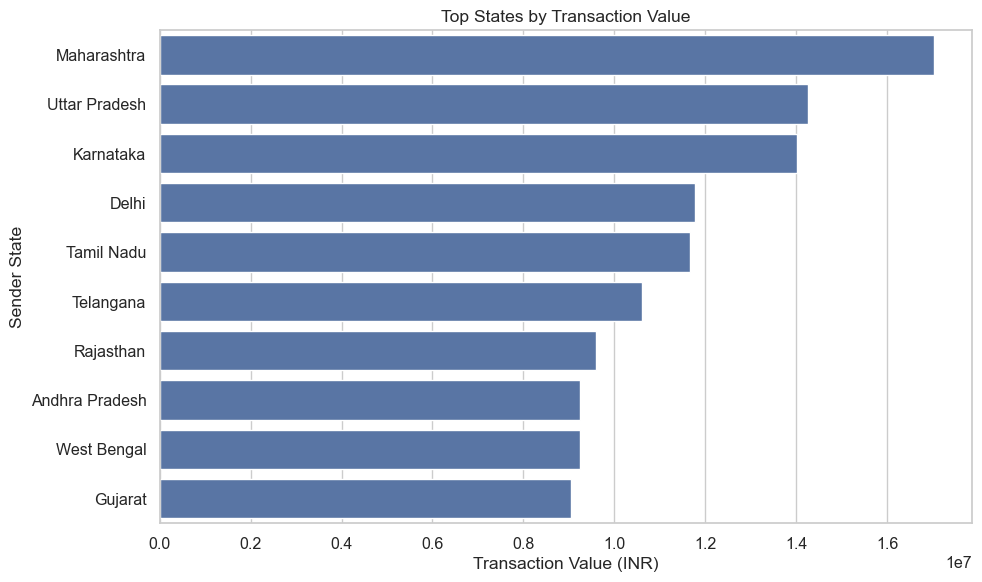

In [13]:
top_states = state.sort_values("transaction_value_inr", ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_states, x="transaction_value_inr", y="sender_state")
plt.title("Top States by Transaction Value")
plt.xlabel("Transaction Value (INR)")
plt.ylabel("Sender State")
plt.tight_layout()
plt.savefig(CHART_DIR / "state_transaction_value.png", dpi=160)
plt.show()


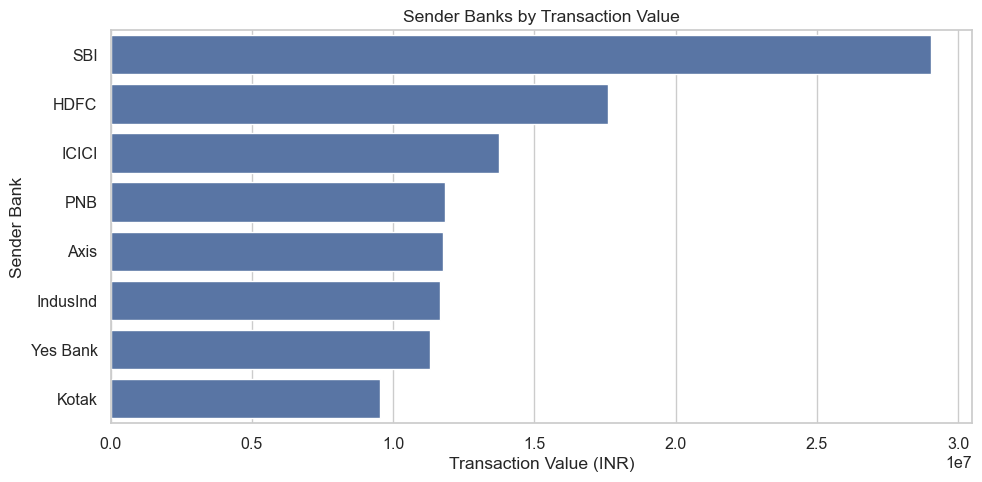

In [14]:
top_banks = sender_bank.sort_values("transaction_value_inr", ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=top_banks, x="transaction_value_inr", y="sender_bank")
plt.title("Sender Banks by Transaction Value")
plt.xlabel("Transaction Value (INR)")
plt.ylabel("Sender Bank")
plt.tight_layout()
plt.savefig(CHART_DIR / "sender_bank_value.png", dpi=160)
plt.show()


## 7. Customer and usage behavior


In [15]:
age_sender = grouped_analysis("sender_age_group")
age_receiver = grouped_analysis("receiver_age_group")
device = grouped_analysis("device_type")
network = grouped_analysis("network_type")

display(age_sender)
display(age_receiver)
display(device)
display(network)

age_sender.to_csv(OUTPUT_DIR / "sender_age_analysis.csv", index=False)
age_receiver.to_csv(OUTPUT_DIR / "receiver_age_analysis.csv", index=False)
device.to_csv(OUTPUT_DIR / "device_analysis.csv", index=False)
network.to_csv(OUTPUT_DIR / "network_analysis.csv", index=False)


,sender_age_group,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,18-25,22078,26548645,"1,202.49",1111,43,5.03,0.19
1,26-35,31465,41450304,"1,317.35",1465,57,4.66,0.18
2,36-45,22291,31464188,"1,411.52",1131,36,5.07,0.16
3,46-55,8685,11642628,"1,340.54",440,17,5.07,0.20
4,56+,4500,5389722,"1,197.72",232,12,5.16,0.27


,receiver_age_group,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,18-25,22268,29165622,"1,309.75",1071,42,4.81,0.19
1,26-35,31208,41083020,"1,316.43",1532,51,4.91,0.16
2,36-45,22223,28806443,"1,296.24",1127,43,5.07,0.19
3,46-55,8866,11572012,"1,305.21",426,23,4.80,0.26
4,56+,4454,5868390,"1,317.56",223,6,5.01,0.13


,device_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,Android,66914,87551282,"1,308.42",3257,127,4.87,0.19
1,Web,4508,5863626,"1,300.72",250,10,5.55,0.22
2,iOS,17597,23080579,"1,311.62",872,28,4.96,0.16


,network_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,3G,4465,5854793,"1,311.26",231,8,5.17,0.18
1,4G,53334,69510714,"1,303.31",2584,94,4.84,0.18
2,5G,22322,29331281,"1,314.01",1135,40,5.08,0.18
3,WiFi,8898,11798699,"1,325.99",429,23,4.82,0.26


In [16]:
weekend = df.groupby("is_weekend").agg(
    transactions=("transaction_id","count"),
    transaction_value_inr=("amount_inr","sum"),
    average_amount_inr=("amount_inr","mean"),
    fraud_flags=("fraud_flag","sum")
).reset_index()
weekend["fraud_flag_rate_pct"] = weekend["fraud_flags"]/weekend["transactions"]*100
display(weekend)


,is_weekend,transactions,transaction_value_inr,average_amount_inr,fraud_flags,fraud_flag_rate_pct
0,0,63699,83386431,"1,309.07",114,0.18
1,1,25320,33109056,"1,307.62",51,0.20


## 8. Time-of-day and day-of-week analysis


In [17]:
hourly = grouped_analysis("hour_of_day")
dow = grouped_analysis("day_of_week")
hourly.to_csv(OUTPUT_DIR / "hourly_analysis.csv", index=False)
dow.to_csv(OUTPUT_DIR / "day_of_week_analysis.csv", index=False)

display(hourly.sort_values("hour_of_day"))
display(dow.sort_values("transactions", ascending=False))


,hour_of_day,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
0,0,1236,1640884,"1,327.58",50,2,4.05,0.16
1,1,798,1025309,"1,284.85",38,3,4.76,0.38
2,2,611,760268,"1,244.30",28,0,4.58,0.00
3,3,498,715297,"1,436.34",25,0,5.02,0.00
4,4,442,537955,"1,217.09",22,0,4.98,0.00
5,5,614,730901,"1,190.39",31,0,5.05,0.00
6,6,1238,1707665,"1,379.37",62,2,5.01,0.16
7,7,2073,2757647,"1,330.27",98,3,4.73,0.14
8,8,2901,3872059,"1,334.73",136,6,4.69,0.21
9,9,3735,4880923,"1,306.81",174,4,4.66,0.11


,day_of_week,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
1,Monday,12994,17043882,"1,311.67",607,19,4.67,0.15
0,Friday,12899,16861916,"1,307.23",626,19,4.85,0.15
3,Sunday,12743,16730689,"1,312.93",656,29,5.15,0.23
6,Wednesday,12624,16405747,"1,299.57",609,30,4.82,0.24
5,Tuesday,12593,16593265,"1,317.66",587,19,4.66,0.15
4,Thursday,12589,16481621,"1,309.21",650,27,5.16,0.21
2,Saturday,12577,16378367,"1,302.25",644,22,5.12,0.17


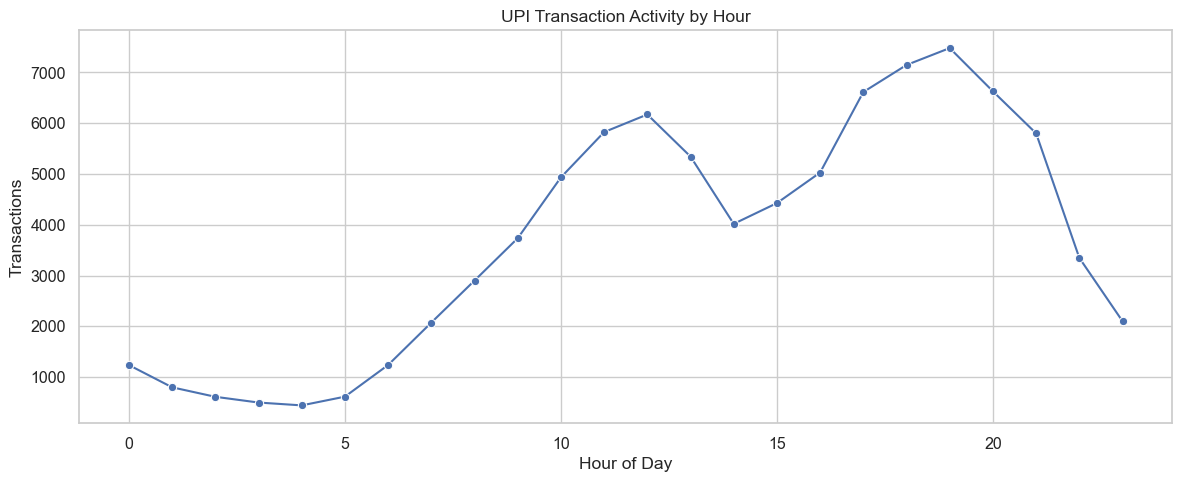

In [18]:
plt.figure(figsize=(12,5))
sns.lineplot(data=hourly.sort_values("hour_of_day"),
             x="hour_of_day", y="transactions", marker="o")
plt.title("UPI Transaction Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.tight_layout()
plt.savefig(CHART_DIR / "hourly_activity.png", dpi=160)
plt.show()


## 9. Fraud-flag analytics


In [19]:
fraud_summary = pd.DataFrame({
    "metric": [
        "Fraud-flagged transactions",
        "Fraud-flagged amount (INR)",
        "Fraud-flag rate (%)"
    ],
    "value": [
        int(df["fraud_flag"].sum()),
        int(df.loc[df["fraud_flag"] == 1, "amount_inr"].sum()),
        df["fraud_flag"].mean()*100
    ]
})
display(fraud_summary)


,metric,value
0,Fraud-flagged transactions,165.00
1,Fraud-flagged amount (INR),"276,959.00"
2,Fraud-flag rate (%),0.19


In [20]:
fraud_by_state = state.sort_values("fraud_flag_rate_pct", ascending=False)
fraud_by_type = transaction_type.sort_values("fraud_flag_rate_pct", ascending=False)
fraud_by_device = device.sort_values("fraud_flag_rate_pct", ascending=False)
fraud_by_network = network.sort_values("fraud_flag_rate_pct", ascending=False)

display(fraud_by_state.head(10))
display(fraud_by_type)
display(fraud_by_device)
display(fraud_by_network)


,sender_state,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
3,Karnataka,10670,14027846,"1,314.70",526,29,4.93,0.27
5,Rajasthan,7144,9603377,"1,344.26",324,19,4.54,0.27
1,Delhi,8827,11767227,"1,333.09",451,20,5.11,0.23
9,West Bengal,7242,9241682,"1,276.12",362,16,5.00,0.22
7,Telangana,8018,10618623,"1,324.35",384,17,4.79,0.21
2,Gujarat,7051,9040220,"1,282.12",311,14,4.41,0.20
8,Uttar Pradesh,10798,14257656,"1,320.40",564,15,5.22,0.14
0,Andhra Pradesh,6999,9249959,"1,321.61",355,9,5.07,0.13
6,Tamil Nadu,9171,11669807,"1,272.47",473,11,5.16,0.12
4,Maharashtra,13099,17019090,"1,299.27",629,15,4.80,0.11


,transaction_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
3,Recharge,4382,5619130,"1,282.32",239,10,5.45,0.23
0,Bill Payment,13351,17412227,"1,304.19",682,26,5.11,0.19
2,P2P,40191,52815672,"1,314.12",1920,73,4.78,0.18
1,P2M,31095,40648458,"1,307.23",1538,56,4.95,0.18


,device_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
1,Web,4508,5863626,"1,300.72",250,10,5.55,0.22
0,Android,66914,87551282,"1,308.42",3257,127,4.87,0.19
2,iOS,17597,23080579,"1,311.62",872,28,4.96,0.16


,network_type,transactions,transaction_value_inr,average_amount_inr,failed_transactions,fraud_flags,failure_rate_pct,fraud_flag_rate_pct
3,WiFi,8898,11798699,"1,325.99",429,23,4.82,0.26
2,5G,22322,29331281,"1,314.01",1135,40,5.08,0.18
0,3G,4465,5854793,"1,311.26",231,8,5.17,0.18
1,4G,53334,69510714,"1,303.31",2584,94,4.84,0.18


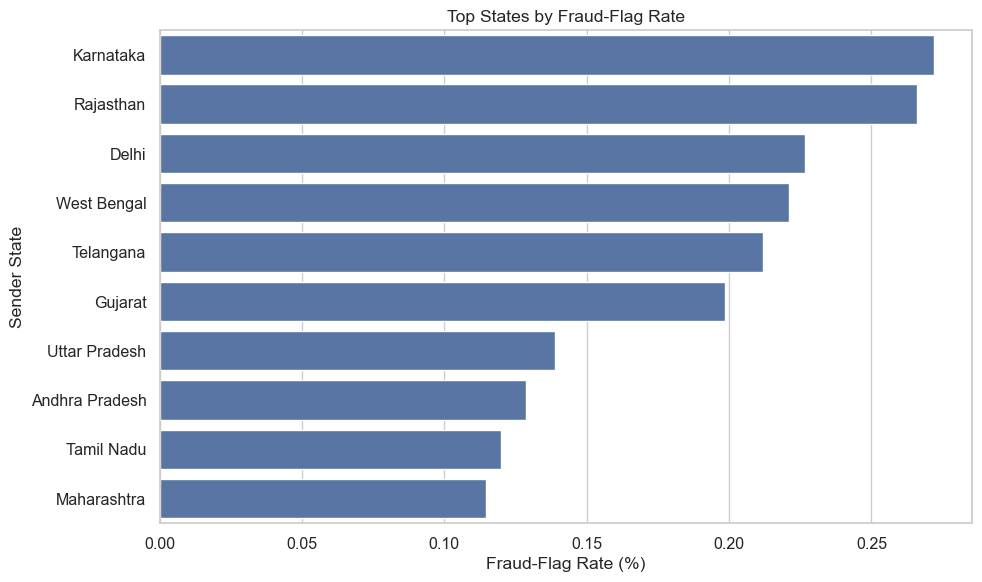

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(data=fraud_by_state.head(10),
            x="fraud_flag_rate_pct", y="sender_state")
plt.title("Top States by Fraud-Flag Rate")
plt.xlabel("Fraud-Flag Rate (%)")
plt.ylabel("Sender State")
plt.tight_layout()
plt.savefig(CHART_DIR / "fraud_rate_by_state.png", dpi=160)
plt.show()


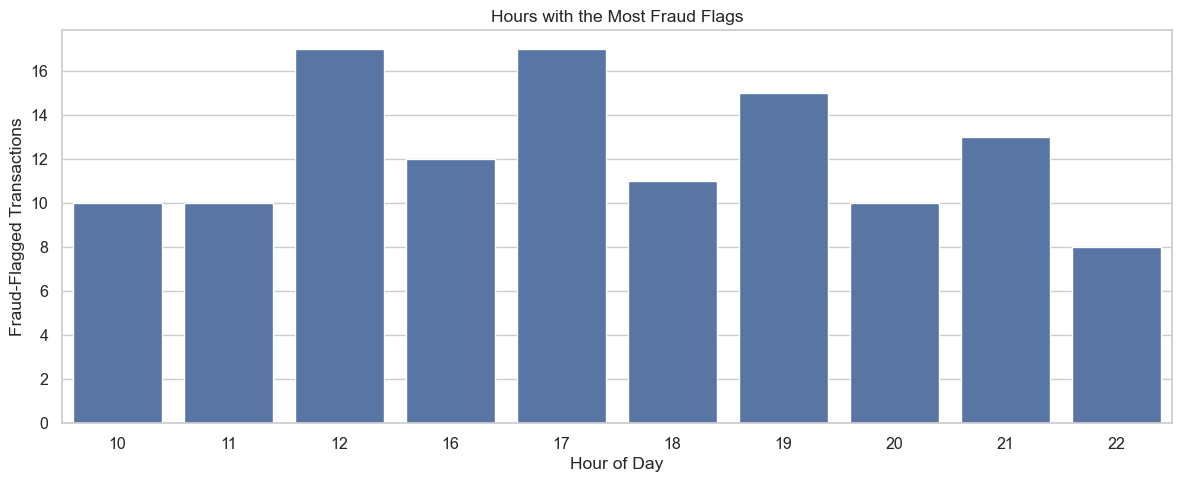

In [22]:
plt.figure(figsize=(12,5))
sns.barplot(data=hourly.sort_values("fraud_flags", ascending=False).head(10),
            x="hour_of_day", y="fraud_flags")
plt.title("Hours with the Most Fraud Flags")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud-Flagged Transactions")
plt.tight_layout()
plt.savefig(CHART_DIR / "fraud_flags_by_hour.png", dpi=160)
plt.show()


## 10. Daily volume anomaly screening


In [23]:
daily = df.assign(date_only=df["timestamp"].dt.date).groupby("date_only").agg(
    transactions=("transaction_id","count"),
    transaction_value_inr=("amount_inr","sum"),
    fraud_flags=("fraud_flag","sum")
).reset_index()

daily["rolling_7d_mean"] = daily["transactions"].rolling(7, min_periods=3).mean()
daily["rolling_7d_std"] = daily["transactions"].rolling(7, min_periods=3).std()
daily["z_score"] = (
    daily["transactions"] - daily["rolling_7d_mean"]
) / daily["rolling_7d_std"].replace(0, np.nan)
daily["potential_volume_anomaly"] = daily["z_score"].abs() >= 2

display(daily.sort_values("z_score", key=lambda s: s.abs(), ascending=False).head(15))
daily.to_csv(OUTPUT_DIR / "daily_anomaly_analysis.csv", index=False)


,date_only,transactions,transaction_value_inr,fraud_flags,rolling_7d_mean,rolling_7d_std,z_score,potential_volume_anomaly
129,2024-05-09,268,299546,0,242.86,11.87,2.12,True
23,2024-01-24,209,244493,0,247.00,17.94,-2.12,True
100,2024-04-10,292,429641,0,257.43,16.76,2.06,True
11,2024-01-12,293,337926,0,252.14,20.43,2.00,False
134,2024-05-14,205,274718,0,248.00,21.59,-1.99,False
148,2024-05-28,210,292212,1,244.00,17.50,-1.94,False
212,2024-07-31,208,241778,0,233.29,13.17,-1.92,False
256,2024-09-13,296,406250,1,239.71,29.66,1.90,False
270,2024-09-27,239,318868,0,253.71,7.89,-1.87,False
271,2024-09-28,225,254817,1,248.57,12.65,-1.86,False


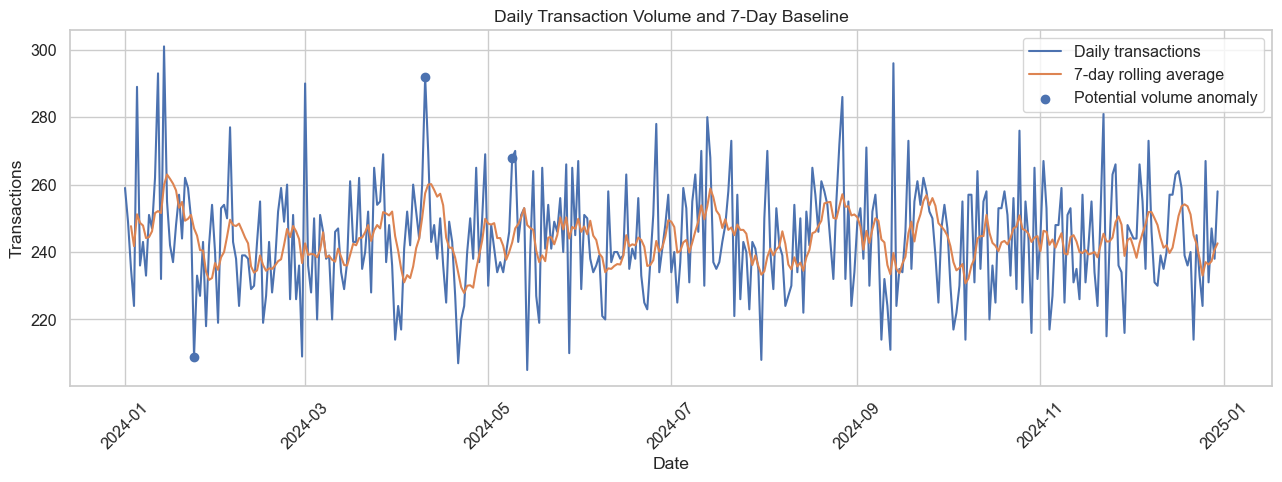

In [24]:
plt.figure(figsize=(13,5))
plt.plot(daily["date_only"], daily["transactions"], label="Daily transactions")
plt.plot(daily["date_only"], daily["rolling_7d_mean"], label="7-day rolling average")
anomalies = daily[daily["potential_volume_anomaly"]]
plt.scatter(anomalies["date_only"], anomalies["transactions"], label="Potential volume anomaly")
plt.title("Daily Transaction Volume and 7-Day Baseline")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "daily_volume_anomalies.png", dpi=160)
plt.show()


## 11. Optional unsupervised amount-anomaly screening


In [25]:
# Optional: screen unusually large/small transaction amounts.
# This is an anomaly screen, NOT a fraud classifier.
q1, q3 = df["amount_inr"].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df["amount_anomaly_iqr"] = (df["amount_inr"] < lower) | (df["amount_inr"] > upper)
print("IQR lower bound:", lower)
print("IQR upper bound:", upper)
print("Amount anomalies:", int(df["amount_anomaly_iqr"].sum()))


IQR lower bound: -1665.0
IQR upper bound: 3543.0
Amount anomalies: 7626


## 12. Are the differences real? Statistical testing
With only 165 fraud-flagged rows, small gaps between groups (for example Web 0.22% vs Android 0.19%) can be pure chance. Each dimension is tested with a **chi-square test of independence** against both `fraud_flag` and `failed`. A p-value below 0.05 would indicate a real association; above it, the ranking should not be read as a finding.

In [26]:
def wilson(k, n, z=1.96):
    """95% Wilson score interval for a proportion (in %)."""
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return 100 * (centre - half), 100 * (centre + half)

dims = ["transaction_type", "merchant_category", "sender_state", "sender_bank",
        "sender_age_group", "device_type", "network_type", "is_weekend", "hour_of_day"]
rows = []
for col in dims:
    for target, label in [("fraud_flag", "fraud-flag"), ("failed", "failure")]:
        chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[col], df[target]))
        rows.append({"dimension": col, "outcome": label, "chi2": chi2, "dof": dof,
                     "p_value": p, "significant_at_5pct": p < 0.05})
tests = pd.DataFrame(rows).sort_values("p_value")
tests["significant_after_bonferroni"] = tests["p_value"] < 0.05 / len(tests)
display(tests)
tests.to_csv(OUTPUT_DIR / "significance_tests.csv", index=False)

# The 18 tests above are run together, so the 5% threshold is also shown after Bonferroni correction.
print(f"Significant at 5%: {int(tests['significant_at_5pct'].sum())} of {len(tests)} tests; "
      f"after Bonferroni correction: {int(tests['significant_after_bonferroni'].sum())}")

,dimension,outcome,chi2,dof,p_value,significant_at_5pct,significant_after_bonferroni
4,sender_state,fraud-flag,16.65,9,0.05,False,False
15,is_weekend,failure,3.44,1,0.06,False,False
9,sender_age_group,failure,7.34,4,0.12,False,False
11,device_type,failure,4.22,2,0.12,False,False
1,transaction_type,failure,5.48,3,0.14,False,False
5,sender_state,failure,11.20,9,0.26,False,False
12,network_type,fraud-flag,2.87,3,0.41,False,False
13,network_type,failure,2.74,3,0.43,False,False
7,sender_bank,failure,6.12,7,0.53,False,False
14,is_weekend,fraud-flag,0.38,1,0.54,False,False


Significant at 5%: 0 of 18 tests; after Bonferroni correction: 0


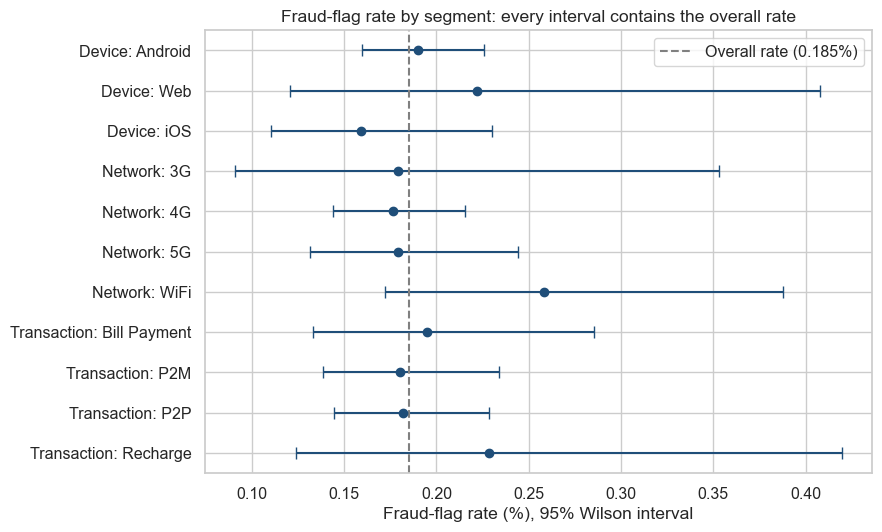

In [27]:
# Fraud-flag rate with 95% confidence intervals: overlapping intervals mean the groups cannot be separated.
ci_rows = []
for col in ["device_type", "network_type", "transaction_type"]:
    g = df.groupby(col)["fraud_flag"].agg(["sum", "count"]).reset_index()
    for _, r in g.iterrows():
        lo, hi = wilson(r["sum"], r["count"])
        ci_rows.append({"group": f"{col.split('_')[0].title()}: {r[col]}",
                        "rate_pct": 100 * r["sum"] / r["count"], "lo": lo, "hi": hi,
                        "flags": int(r["sum"]), "n": int(r["count"])})
ci = pd.DataFrame(ci_rows).iloc[::-1].reset_index(drop=True)
ci.to_csv(OUTPUT_DIR / "fraud_rate_confidence_intervals.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(ci["rate_pct"], range(len(ci)),
            xerr=[ci["rate_pct"] - ci["lo"], ci["hi"] - ci["rate_pct"]],
            fmt="o", capsize=4, color="#1f4e79")
ax.axvline(df["fraud_flag"].mean() * 100, ls="--", color="grey", label="Overall rate (0.185%)")
ax.set_yticks(range(len(ci))); ax.set_yticklabels(ci["group"])
ax.set_xlabel("Fraud-flag rate (%), 95% Wilson interval")
ax.set_title("Fraud-flag rate by segment: every interval contains the overall rate")
ax.legend(); plt.tight_layout()
plt.savefig(CHART_DIR / "fraud_rate_confidence_intervals.png", dpi=160); plt.show()

## 13. Deeper behavioral patterns

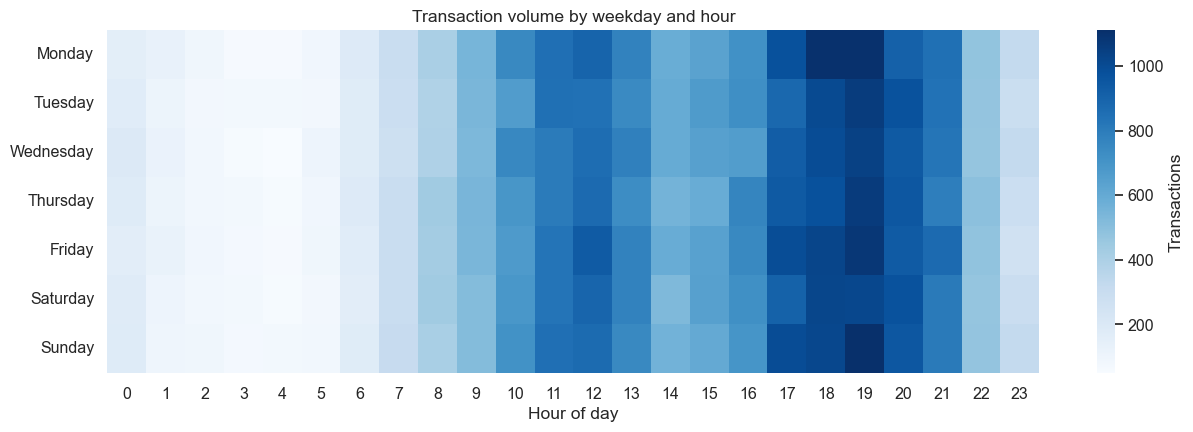

Peak hour: 19 with 7481 transactions; quietest hour: 4 with 442


In [28]:
# When does activity happen? Hour x weekday volume heatmap.
heat = df.pivot_table(index="day_of_week", columns="hour_of_day", values="transaction_id", aggfunc="count")
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = heat.loc[order]
plt.figure(figsize=(13, 4.5))
sns.heatmap(heat, cmap="Blues", cbar_kws={"label": "Transactions"})
plt.title("Transaction volume by weekday and hour")
plt.xlabel("Hour of day"); plt.ylabel("")
plt.tight_layout(); plt.savefig(CHART_DIR / "hour_weekday_heatmap.png", dpi=160); plt.show()
heat.to_csv(OUTPUT_DIR / "hour_weekday_heatmap.csv")

peak = df.groupby("hour_of_day").size()
print("Peak hour:", int(peak.idxmax()), "with", int(peak.max()), "transactions;",
      "quietest hour:", int(peak.idxmin()), "with", int(peak.min()))

C:\Users\shiva\AppData\Local\Temp\ipykernel_6024\1877989403.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not flagged", "Fraud-flagged"]); axes[1].set_xlabel("")


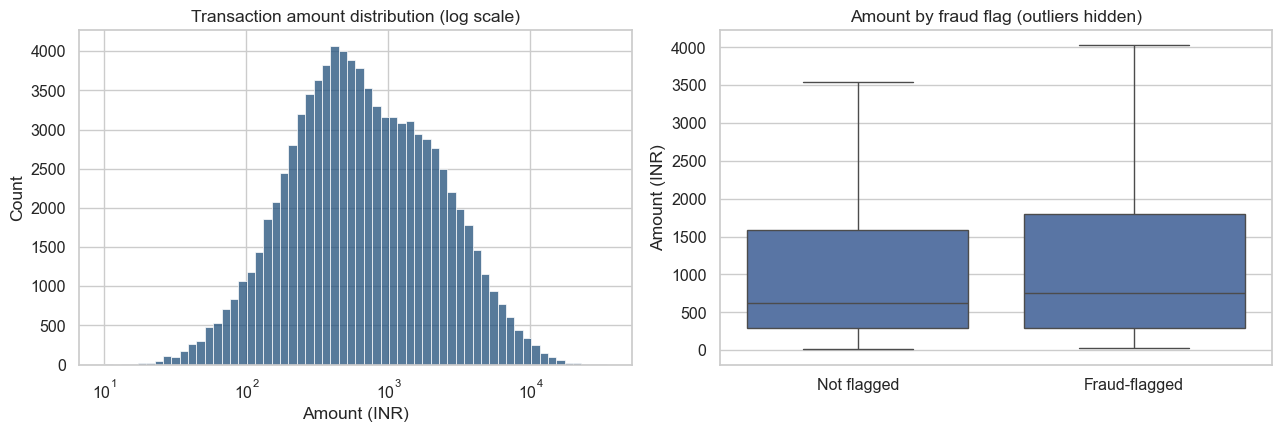

Median amount: flagged INR 754 vs not flagged INR 628
Mann-Whitney U test p-value: 0.1113


,amount_band,transactions,fraud_flags,failed,fraud_flag_rate_pct,failure_rate_pct
0,<250,18806,35,921,0.19,4.90
1,250-500,19245,28,907,0.15,4.71
2,500-1k,18108,28,875,0.15,4.83
3,1k-2.5k,19871,42,1030,0.21,5.18
4,2.5k-5k,9081,16,441,0.18,4.86
5,5k+,3908,16,205,0.41,5.25


All amount bands, chi-square p = 0.0159
5k+ vs the rest (Fisher exact): odds ratio = 2.34, p = 0.0032
This comparison was chosen after looking at the data, so treat it as a hypothesis for review, not a conclusion.


In [29]:
# Amounts are heavily right-skewed, so a log axis is used and rank-based tests are preferred over means.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["amount_inr"], bins=60, log_scale=True, ax=axes[0], color="#1f4e79")
axes[0].set_title("Transaction amount distribution (log scale)"); axes[0].set_xlabel("Amount (INR)")
sns.boxplot(data=df, x="fraud_flag", y="amount_inr", showfliers=False, ax=axes[1])
axes[1].set_xticklabels(["Not flagged", "Fraud-flagged"]); axes[1].set_xlabel("")
axes[1].set_title("Amount by fraud flag (outliers hidden)"); axes[1].set_ylabel("Amount (INR)")
plt.tight_layout(); plt.savefig(CHART_DIR / "amount_distribution.png", dpi=160); plt.show()

u, p_mw = stats.mannwhitneyu(df.loc[df.fraud_flag == 1, "amount_inr"],
                             df.loc[df.fraud_flag == 0, "amount_inr"], alternative="two-sided")
print(f"Median amount: flagged INR {df.loc[df.fraud_flag==1,'amount_inr'].median():,.0f} "
      f"vs not flagged INR {df.loc[df.fraud_flag==0,'amount_inr'].median():,.0f}")
print(f"Mann-Whitney U test p-value: {p_mw:.4f}")

bands = pd.cut(df["amount_inr"], [0, 250, 500, 1000, 2500, 5000, np.inf],
               labels=["<250", "250-500", "500-1k", "1k-2.5k", "2.5k-5k", "5k+"])
band_tbl = df.groupby(bands, observed=True).agg(transactions=("transaction_id", "count"),
            fraud_flags=("fraud_flag", "sum"), failed=("failed", "sum")).reset_index(names="amount_band")
band_tbl["fraud_flag_rate_pct"] = band_tbl.fraud_flags / band_tbl.transactions * 100
band_tbl["failure_rate_pct"] = band_tbl.failed / band_tbl.transactions * 100
display(band_tbl); band_tbl.to_csv(OUTPUT_DIR / "amount_band_analysis.csv", index=False)

# The 5k+ band shows the highest fraud-flag rate. This looks like a lead, so it is tested, not assumed.
chi_b = stats.chi2_contingency(pd.crosstab(bands, df["fraud_flag"]))
top = df["amount_inr"] >= 5000
odds, p_fisher = stats.fisher_exact(pd.crosstab(top, df["fraud_flag"]))
print(f"All amount bands, chi-square p = {chi_b[1]:.4f}")
print(f"5k+ vs the rest (Fisher exact): odds ratio = {odds:.2f}, p = {p_fisher:.4f}")
print("This comparison was chosen after looking at the data, so treat it as a hypothesis for review, not a conclusion.")

In [30]:
# Who pays whom: intra-bank share and monthly growth.
same_bank = (df["sender_bank"] == df["receiver_bank"]).mean() * 100
print(f"Same-bank transfers: {same_bank:.1f}% of transactions")
monthly["volume_change_pct"] = monthly["transactions"].pct_change() * 100
monthly["value_change_pct"] = monthly["transaction_value_inr"].pct_change() * 100
display(monthly[["year_month", "transactions", "volume_change_pct", "value_change_pct"]])

# Months differ in length (2024 is a leap year), so expected volume is proportional to days in the data, not equal.
days = df.groupby("year_month")["date"].nunique().reindex(monthly["year_month"]).to_numpy()
expected = monthly["transactions"].sum() * days / days.sum()
chi_m = stats.chisquare(monthly["transactions"], expected)
print(f"Monthly volume vs day-adjusted expectation (chi-square): p = {chi_m.pvalue:.4f}")
print("Average transactions per active day:", round(monthly["transactions"].sum() / days.sum(), 1))

Same-bank transfers: 14.5% of transactions


,year_month,transactions,volume_change_pct,value_change_pct
0,2024-01,7674,NaN,NaN
1,2024-02,6953,-9.40,-7.50
2,2024-03,7553,8.63,8.92
3,2024-04,7313,-3.18,-3.65
4,2024-05,7595,3.86,4.06
5,2024-06,7230,-4.81,-6.40
6,2024-07,7559,4.55,6.28
7,2024-08,7632,0.97,0.65
8,2024-09,7375,-3.37,-2.62
9,2024-10,7499,1.68,2.48


Monthly volume vs day-adjusted expectation (chi-square): p = 0.8023
Average transactions per active day: 243.9


In [31]:
# IQR amount screen summary (extends section 11): who gets flagged as an amount outlier?
print(f"Amount outliers: {int(df['amount_anomaly_iqr'].sum()):,} "
      f"({df['amount_anomaly_iqr'].mean()*100:.2f}% of transactions)")
iqr_flag = df.groupby("amount_anomaly_iqr")["fraud_flag"].agg(["sum", "count", "mean"])
iqr_flag["mean"] *= 100
display(iqr_flag.rename(columns={"sum": "fraud_flags", "count": "transactions", "mean": "fraud_flag_rate_pct"}))
print("The IQR screen is a statistical outlier filter. It does not predict the supplied fraud flag.")

Amount outliers: 7,626 (8.57% of transactions)


,fraud_flags,transactions,fraud_flag_rate_pct
amount_anomaly_iqr,,,
False,141,81393,0.17
True,24,7626,0.31


The IQR screen is a statistical outlier filter. It does not predict the supplied fraud flag.


## 14. Export final analytical tables and the dashboard data feed

In [32]:
executive = {
    "total_transactions": int(total_transactions),
    "total_transaction_value_inr": float(total_value),
    "average_transaction_inr": float(average_amount),
    "median_transaction_inr": float(median_amount),
    "successful_transactions": int(successful),
    "failed_transactions": int(failed),
    "success_rate_pct": float(successful / total_transactions * 100),
    "failure_rate_pct": float(failed / total_transactions * 100),
    "fraud_flagged_transactions": int(fraud_flagged),
    "fraud_flag_rate_pct": float(fraud_flagged / total_transactions * 100),
    "fraud_flagged_amount_inr": float(fraud_flagged_amount),
    "daily_volume_anomaly_days": int(daily["potential_volume_anomaly"].sum()),
    "significant_tests_5pct": int(tests["significant_at_5pct"].sum()),
    "tests_run": int(len(tests)),
}
with open(OUTPUT_DIR / "executive_summary.json", "w", encoding="utf-8") as f:
    json.dump(executive, f, indent=2)

# One small JS file feeds the static dashboard, so it opens by double-click with no server.
def recs(frame, cols):
    return json.loads(frame[cols].round(3).to_json(orient="records"))

dash = {
    "kpi": executive,
    "monthly": recs(monthly, ["year_month", "transactions", "transaction_value_inr", "failure_rate_pct", "fraud_flags"]),
    "types": recs(transaction_type.sort_values("transactions", ascending=False),
                  ["transaction_type", "transactions", "transaction_value_inr", "average_amount_inr", "failure_rate_pct"]),
    "merchants": recs(merchant.sort_values("transactions", ascending=False),
                      ["merchant_category", "transactions", "transaction_value_inr", "failure_rate_pct"]),
    "states": recs(state.sort_values("transaction_value_inr", ascending=False),
                   ["sender_state", "transactions", "transaction_value_inr", "fraud_flags", "fraud_flag_rate_pct"]),
    "banks": recs(sender_bank.sort_values("transaction_value_inr", ascending=False),
                  ["sender_bank", "transactions", "transaction_value_inr", "failure_rate_pct"]),
    "hourly": recs(hourly.sort_values("hour_of_day"), ["hour_of_day", "transactions", "fraud_flags"]),
    "heatmap": {"days": order, "values": heat.values.tolist()},
    "daily": [{"d": str(r.date_only), "n": int(r.transactions), "m": None if pd.isna(r.rolling_7d_mean) else round(r.rolling_7d_mean, 1),
               "a": bool(r.potential_volume_anomaly)} for r in daily.itertuples()],
    "ci": recs(ci.iloc[::-1], ["group", "rate_pct", "lo", "hi", "flags", "n"]),
    "tests": recs(tests, ["dimension", "outcome", "p_value", "significant_at_5pct"]),
}
(DASH_DIR / "data.js").write_text("window.UPI_DATA = " + json.dumps(dash, separators=(",", ":")) + ";", encoding="utf-8")

print("Analysis completed successfully.")
print(json.dumps(executive, indent=2))

Analysis completed successfully.
{
  "total_transactions": 89019,
  "total_transaction_value_inr": 116495487.0,
  "average_transaction_inr": 1308.6586796077243,
  "median_transaction_inr": 628.0,
  "successful_transactions": 84640,
  "failed_transactions": 4379,
  "success_rate_pct": 95.08082544175961,
  "failure_rate_pct": 4.919174558240376,
  "fraud_flagged_transactions": 165,
  "fraud_flag_rate_pct": 0.18535368853840192,
  "fraud_flagged_amount_inr": 276959.0,
  "daily_volume_anomaly_days": 3,
  "significant_tests_5pct": 0,
  "tests_run": 18
}
